In [1]:
import networkx as nx
import polars as pl
import torch
from torch import Tensor

from src.config import PROCESSED_DATA_DIR
from src.db import PBWarehouse

pb = PBWarehouse()
data = pl.read_csv(PROCESSED_DATA_DIR / "hatebert-test.csv", schema={
        "tweet_id": pl.Utf8,
        "text": pl.Utf8,
        "status_link": pl.Utf8,
        "user_id": pl.Utf8,
        "is_extremist": pl.Boolean,
        "is_annotated": pl.Boolean,
        "in_reply_to_status_link": pl.Utf8,
        "in_reply_to_status_id": pl.Utf8,
        "bookmark_count": pl.Int64,
        "views": pl.Int64,
        "retweet_count": pl.Int64,
        "favorite_count": pl.Int64,
        "reply_count": pl.Int64,
        "quote_count": pl.Int64,
        "conversation_id": pl.Utf8,
        "retweet_tweet_id": pl.Utf8,
        "quoted_status_id": pl.Utf8,
        "community_note": pl.Utf8,
        "language": pl.Utf8,
        "source": pl.Utf8,
        "creation_date": pl.Utf8,
        "has_blm_hashtag": pl.Boolean,
        "fetched_replies": pl.Boolean,
        "is_reply_to_blm": pl.Boolean,
        "is_hateful": pl.Int8,
    })

2025-07-13 08:21:14.402 | INFO     | src.config:<module>:26 - Loaded environment variables from /home/iragca/Documents/github/capstone-project-2/.env
2025-07-13 08:21:14.402 | INFO     | src.config:<module>:60 - PROJECT_ROOT: /home/iragca/Documents/github/capstone-project-2
2025-07-13 08:21:14.403 | INFO     | src.config:<module>:61 - DATA_DIR: /home/iragca/Documents/github/capstone-project-2/data


In [2]:
data 

tweet_id,text,status_link,user_id,is_extremist,is_annotated,in_reply_to_status_link,in_reply_to_status_id,bookmark_count,views,retweet_count,favorite_count,reply_count,quote_count,conversation_id,retweet_tweet_id,quoted_status_id,community_note,language,source,creation_date,has_blm_hashtag,fetched_replies,is_reply_to_blm,is_hateful
str,str,str,str,bool,bool,str,str,i64,i64,i64,i64,i64,i64,str,str,str,str,str,str,str,bool,bool,bool,i8
"""1269916756719685632""","""@TRCdocumentary @Blklivesmatte…","""https://x.com/hypersoses/statu…","""1264846057906806786""",false,false,"""https://x.com/TRCdocumentary/s…","""1266515065190170625""",0,0,0,0,0,0,"""1266484388491116550""",null,"""""","""""","""en""","""""","""2020-06-08T08:58:43.000""",false,false,true,1
"""1277976913743503365""","""@terrycrews @jonathanwsabin Th…","""https://x.com/TheJaredMonroe/s…","""23719684""",false,false,"""https://x.com/terrycrews/statu…","""1277955144332668930""",23,0,156,4860,334,28,"""1277955144332668930""",null,"""""","""""","""en""","""""","""2020-06-30T14:46:54.000""",true,true,true,1
"""1285714950896443395""","""Join Bernie and Sunrise leader…","""https://x.com/SunriseMvmtHTX/s…","""1081973336010309632""",false,false,"""""","""""",0,0,0,2,0,0,"""1285714950896443395""",null,"""""","""""","""en""","""Hootsuite Inc.""","""2020-07-21T23:15:06.000""",true,false,false,1
"""1284209535561818112""","""@prageru It's not the women's …","""https://x.com/chekmate111/stat…","""190751291""",false,false,"""https://x.com/prageru/status/1…","""1284205227319730176""",0,0,0,4,1,0,"""1284205227319730176""",null,"""""","""""","""en""","""""","""2020-07-17T19:33:07.000""",false,false,true,1
"""1575540451486011392""","""Imagine being homeless, then t…","""https://x.com/UnionBaddieMatt/…","""1535727235155607553""",false,false,"""""","""""",0,0,1,5,1,0,"""1575540451486011392""",null,"""""","""""","""en""","""Twitter for Android""","""2022-09-29T17:38:10.000""",true,true,false,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""1243348301900140544""","""You shouldn’t get down to the …","""https://x.com/great_african/st…","""1082588920414720000""",false,false,"""""","""""",0,0,0,1,0,0,"""1243348301900140544""",null,"""""","""""","""en""","""Twitter for iPhone""","""2020-03-27T01:25:10.000""",true,false,false,1
"""1269549033053290499""","""@AmberLotus21 @David76583783 D…","""https://x.com/ActivelyWoke1/st…","""553976157""",false,false,"""https://x.com/AmberLotus21/sta…","""1266926269876195328""",0,0,1,1,1,0,"""1266926269876195328""",null,"""""","""""","""en""","""""","""2020-06-07T08:37:31.000""",false,true,true,1
"""1242028539546828801""","""Overseas #American #Voters Req…","""https://x.com/DemsAbroadDE/sta…","""860520162939850752""",false,false,"""""","""""",0,0,1,1,0,0,"""1242028539546828801""",null,"""""","""""","""en""","""SocialPilot.co""","""2020-03-23T10:00:54.000""",true,false,false,1


In [3]:
data = data.with_columns(
    pl.col("user_id").map_elements(lambda user_id: pb.get_user_by_id(user_id), return_dtype=pl.Struct).alias("user_info")
)

In [4]:
df = (
    data.with_columns([pl.col("creation_date").alias("tweet_creation_date")])
    .drop(["creation_date", "user_id"])
    .unnest("user_info")
    # .select(["tweet_id", "is_hateful", "conversation_id", "user_id"])
)
df

tweet_id,text,status_link,is_extremist,is_annotated,in_reply_to_status_link,in_reply_to_status_id,bookmark_count,views,retweet_count,favorite_count,reply_count,quote_count,conversation_id,retweet_tweet_id,quoted_status_id,community_note,language,source,has_blm_hashtag,fetched_replies,is_reply_to_blm,is_hateful,id,created,updated,expand,bot,collection_id,collection_name,creation_date,description,favourites_count,follower_count,following_count,is_blue_verified,is_private,is_verified,listed_count,location,name,number_of_tweets,user_id,username,tweet_creation_date
str,str,str,bool,bool,str,str,i64,i64,i64,i64,i64,i64,str,str,str,str,str,str,bool,bool,bool,i8,str,datetime[μs],datetime[μs],struct[0],bool,str,str,str,str,i64,i64,i64,bool,bool,bool,i64,str,str,i64,str,str,str
"""1269916756719685632""","""@TRCdocumentary @Blklivesmatte…","""https://x.com/hypersoses/statu…",false,false,"""https://x.com/TRCdocumentary/s…","""1266515065190170625""",0,0,0,0,0,0,"""1266484388491116550""",null,"""""","""""","""en""","""""",false,false,true,1,"""452x1awk5pv27f1""",2025-07-11 12:19:11,2025-07-11 12:19:11,{},false,"""pbc_2025413586""","""tweet_users""","""2020-05-25 09:10:25.000Z""","""""",941,39,6,false,false,false,0,"""Turkey""","""hypersoses""",422,"""1264846057906806786""","""hypersoses""","""2020-06-08T08:58:43.000"""
"""1277976913743503365""","""@terrycrews @jonathanwsabin Th…","""https://x.com/TheJaredMonroe/s…",false,false,"""https://x.com/terrycrews/statu…","""1277955144332668930""",23,0,156,4860,334,28,"""1277955144332668930""",null,"""""","""""","""en""","""""",true,true,true,1,"""rpfnk5c4k57a728""",2025-07-11 12:19:11,2025-07-11 12:19:11,{},false,"""pbc_2025413586""","""tweet_users""","""2009-03-11 04:02:39.000Z""","""Founder of Honest Fox Media.""",13269,95956,1596,true,false,false,245,"""""","""Jared Monroe""",21715,"""23719684""","""TheJaredMonroe""","""2020-06-30T14:46:54.000"""
"""1285714950896443395""","""Join Bernie and Sunrise leader…","""https://x.com/SunriseMvmtHTX/s…",false,false,"""""","""""",0,0,0,2,0,0,"""1285714950896443395""",null,"""""","""""","""en""","""Hootsuite Inc.""",true,false,false,1,"""sqz7mw1ndb8i5lp""",2025-07-11 12:19:11,2025-07-11 12:19:11,{},false,"""pbc_2025413586""","""tweet_users""","""2019-01-06 17:58:40.000Z""","""We are a local movement of you…",1494,1394,427,false,false,false,30,"""Houston, TX""","""Sunrise Movement Houston 🌅""",1173,"""1081973336010309632""","""SunriseMvmtHTX""","""2020-07-21T23:15:06.000"""
"""1284209535561818112""","""@prageru It's not the women's …","""https://x.com/chekmate111/stat…",false,false,"""https://x.com/prageru/status/1…","""1284205227319730176""",0,0,0,4,1,0,"""1284205227319730176""",null,"""""","""""","""en""","""""",false,false,true,1,"""td96gzjka0ejnuc""",2025-07-11 12:19:11,2025-07-11 12:19:11,{},false,"""pbc_2025413586""","""tweet_users""","""2010-09-14 19:06:31.000Z""","""This is the real ChekMate111""",2675,49,165,false,false,false,3,"""""","""Eberly""",1866,"""190751291""","""chekmate111""","""2020-07-17T19:33:07.000"""
"""1575540451486011392""","""Imagine being homeless, then t…","""https://x.com/UnionBaddieMatt/…",false,false,"""""","""""",0,0,1,5,1,0,"""1575540451486011392""",null,"""""","""""","""en""","""Twitter for Android""",true,true,false,1,"""hrjgj1dyvtubjc9""",2025-07-11 12:19:11,2025-07-11 12:19:11,{},false,"""pbc_2025413586""","""tweet_users""","""2022-06-11 20:55:04.000Z""","""25, Enby & Pan. TroubleMaker w…",40284,2861,7485,false,false,false,8,"""""KY"" is occupied Shawnee land""","""🇵🇸🇱🇧🇨🇩DecolonizeUnions🇻🇳🇨🇺🇧🇫""",26333,"""1535727235155607553""","""UnionBaddieMatt""","""2022-09-29T17:38:10.000"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""1243348301900140544""","""You shouldn’t get down to the …","""https://x.com/great_african/st…",false,false,"""""","""""",0,0,0,1,0,0,"""1243348301900140544""",null,"""""","""""","""en""","""Twitter for iPhone""",true,false,false,1,"""ri3hoa9c1cj099o""",2025

In [34]:
df.drop(["expand"]).write_csv(PROCESSED_DATA_DIR / "hatebert-test_with_users.csv")

## Making a networkx graph dataset

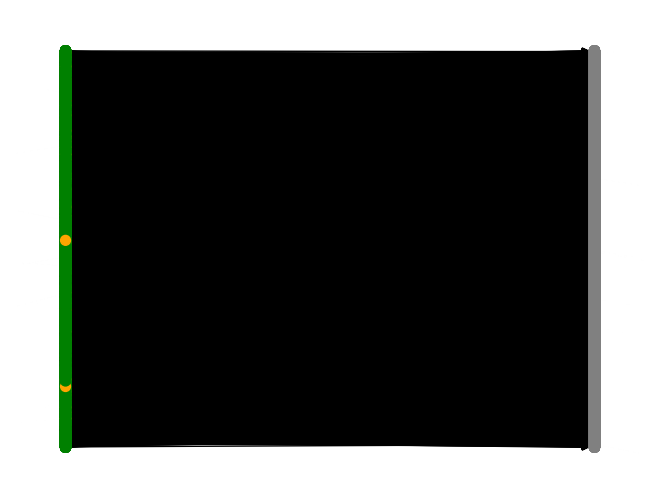

In [21]:
G = nx.DiGraph()
##                  ID:color
community_map: dict[str:int] = {}
color_map = {0: "gray", 1: "red", 2: "green", 3: "orange",}

for row in df.iter_rows(named=True):

    tweet_id = row["tweet_id"]
    is_hateful = row["is_hateful"]
    user_id = row["user_id"]

    tweet_features = torch.tensor([
            row["retweet_count"],
            row["favorite_count"],
            row["bookmark_count"],
            row["reply_count"],
            row["quote_count"],
            row["views"],
            row["is_hateful"],
        ], dtype=torch.float32)
    
    user_features = torch.tensor([
        row["favourites_count"],
        row["follower_count"],
        row["following_count"],
        row["number_of_tweets"],
        row["listed_count"],
        row["is_blue_verified"],
        0
    ], dtype=torch.float32)


    G.add_node(tweet_id, node_label=is_hateful, bipartite=0, node_feature=tweet_features)
    G.add_node(user_id, node_label=3, bipartite=1, node_feature=user_features)
    if tweet_id and user_id:
        G.add_edge(tweet_id, user_id)
       
for node in G.nodes(data=True):
    if "node_label" in node[1]:

        match node[1]["node_label"]:
            case 0:
                community_map[node[0]] = 1
            case 1:
                community_map[node[0]] = 2
            case 2:
                community_map[node[0]] = 3
            case _:
                # If the is_hateful value is not recognized, assign it to community 0 / gray
                community_map[node[0]] = 0
    else:
        # If node is a user, assign it to community 0 / gray
        community_map[node[0]] = 0

node_colors = [color_map[community_map[node]] for node in G.nodes()]

top_nodes = [node for node, attributes in G.nodes(data=True) if attributes["bipartite"] == 0]
pos = nx.bipartite_layout(G, top_nodes)
nx.draw(G, pos=pos, node_color=node_colors, node_size=10)

In [22]:
from deepsnap.hetero_graph import Graph
from deepsnap.dataset import GraphDataset

graph = Graph(G)

In [23]:
dataset = GraphDataset([graph], task='link_pred', edge_train_mode='all')

dataset_train, dataset_val, dataset_test = dataset.split(transductive=True, split_ratio=[0.4, 0.3, 0.3])
titles = ['Train', 'Validation', 'Test']


In [24]:
dataset_train[0]

Graph(G=[], bipartite=[72151], edge_index=[2, 16880], edge_label=[33760], edge_label_index=[2, 33760], negative_label_val=[1], node_feature=[72151, 7], node_label=[72151], node_label_index=[72151])

In [25]:
import copy
import torch
import torch.nn as nn
import networkx as nx
import torch.nn.functional as F
import matplotlib.pyplot as plt

from deepsnap.graph import Graph
from deepsnap.batch import Batch
from deepsnap.dataset import GraphDataset
from sklearn.metrics import roc_auc_score, f1_score
from torch_geometric.datasets import Planetoid, TUDataset
from torch.utils.data import DataLoader
from torch_geometric.nn import SAGEConv

class LinkPredModel(torch.nn.Module):
    def __init__(self, input_size, hidden_size):
        super(LinkPredModel, self).__init__()

        self.conv1 = SAGEConv(input_size, hidden_size)
        self.conv2 = SAGEConv(hidden_size, hidden_size)
        self.bn1 = nn.BatchNorm1d(hidden_size)
        self.bn2 = nn.BatchNorm1d(hidden_size)
        self.loss_fn = torch.nn.BCEWithLogitsLoss()

    def forward(self, batch):
        x, edge_index, edge_label_index = batch.node_feature, batch.edge_index, batch.edge_label_index

        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.leaky_relu(x)
        x = self.conv2(x, edge_index)
        x = self.bn2(x)

        nodes_first = torch.index_select(x, 0, edge_label_index[0,:].long())
        nodes_second = torch.index_select(x, 0, edge_label_index[1,:].long())
        pred = torch.sum(nodes_first * nodes_second, dim=-1)
        return pred

    def loss(self, pred, label):
        return self.loss_fn(pred, label)

In [30]:
def train(model, dataloaders, optimizer, args):
    val_max = 0
    best_model = model

    for epoch in range(1, args["epochs"]):
        for i, batch in enumerate(dataloaders['train']):

            batch.to(args["device"])
            model.train()
            optimizer.zero_grad()
            pred = model(batch)
            loss = model.loss(pred, batch.edge_label.type(pred.dtype))
            # print(pred[0], batch.edge_label.type(pred.dtype)[0])
            loss.backward()
            optimizer.step()

            log = 'Epoch: {:03d}, Train: {:.4f}, Val: {:.4f}, Test: {:.4f}, Loss: {:.5f}'
            score_train = test(model, dataloaders['train'], args)
            score_val = test(model, dataloaders['val'], args)
            score_test = test(model, dataloaders['test'], args)

            print(log.format(epoch, score_train, score_val, score_test, loss.item()))
            if val_max < score_val:
                val_max = score_val
                best_model = copy.deepcopy(model)
    return best_model

def test(model, dataloader, args):
    model.eval()
    score = 0
    f1_score_count = 0
    num_batches = 0
    for batch in dataloader:
        batch.to(args["device"])
        pred = model(batch)
        pred = torch.sigmoid(pred)
        # print(pred)
        score += roc_auc_score(batch.edge_label.flatten().cpu().numpy(), pred.flatten().data.cpu().numpy())
        pred_labels = (pred > 0.2).float()
        f1_score_count += f1_score(batch.edge_label.flatten().cpu().numpy(), pred_labels.flatten().data.cpu().numpy(), zero_division=0)
        num_batches += 1
    score /= num_batches
    f1_score_count /= num_batches
    print(f"F1 Score: {f1_score_count:.4f}")
    # print(f"ROC AUC Score: {score:.4f}")
    return score

In [31]:
args = {
    "device" : 'cuda' if torch.cuda.is_available() else 'cpu',
    "hidden_dim" : 128,
    "epochs" : 150,
}


dataset = GraphDataset(
        [graph],
        task='link_pred',
        edge_train_mode="disjoint"
    )
datasets = {}
datasets['train'], datasets['val'], datasets['test']= dataset.split(
            transductive=True, split_ratio=[0.85, 0.05, 0.1])
input_dim = datasets['train'].num_node_features
num_classes = datasets['train'].num_edge_labels

model = LinkPredModel(input_dim, args["hidden_dim"]).to(args["device"])

optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)

dataloaders = {split: DataLoader(
            ds, collate_fn=Batch.collate([]),
            batch_size=1, shuffle=(split=='train'))
            for split, ds in datasets.items()}
best_model = train(model, dataloaders, optimizer, args)
log = "Train: {:.4f}, Val: {:.4f}, Test: {:.4f}"
best_train_roc = test(best_model, dataloaders['train'], args)
best_val_roc = test(best_model, dataloaders['val'], args)
best_test_roc = test(best_model, dataloaders['test'], args)
print(log.format(best_train_roc, best_val_roc, best_test_roc))

F1 Score: 0.5652
F1 Score: 0.5746
F1 Score: 0.5640
Epoch: 001, Train: 0.2531, Val: 0.2642, Test: 0.2615, Loss: 5.98796
F1 Score: 0.6631
F1 Score: 0.6624
F1 Score: 0.6623
Epoch: 002, Train: 0.4075, Val: 0.3951, Test: 0.4128, Loss: 2.30903
F1 Score: 0.6667
F1 Score: 0.6667
F1 Score: 0.6667
Epoch: 003, Train: 0.5183, Val: 0.5171, Test: 0.5419, Loss: 0.90210
F1 Score: 0.6667
F1 Score: 0.6667
F1 Score: 0.6667
Epoch: 004, Train: 0.5431, Val: 0.5467, Test: 0.5705, Loss: 0.78244
F1 Score: 0.6667
F1 Score: 0.6667
F1 Score: 0.6667
Epoch: 005, Train: 0.5511, Val: 0.5603, Test: 0.5807, Loss: 0.82055
F1 Score: 0.6667
F1 Score: 0.6667
F1 Score: 0.6667
Epoch: 006, Train: 0.5613, Val: 0.5658, Test: 0.5864, Loss: 0.86980
F1 Score: 0.6667
F1 Score: 0.6667
F1 Score: 0.6667
Epoch: 007, Train: 0.5540, Val: 0.5699, Test: 0.5900, Loss: 0.94483
F1 Score: 0.6667
F1 Score: 0.6667
F1 Score: 0.6667
Epoch: 008, Train: 0.5666, Val: 0.5741, Test: 0.5938, Loss: 0.96942
F1 Score: 0.6667
F1 Score: 0.6667
F1 Score: 0.66

In [80]:
model

LinkPredModel(
  (conv1): SAGEConv(7, 128, aggr=mean)
  (conv2): SAGEConv(128, 128, aggr=mean)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (loss_fn): BCEWithLogitsLoss()
)

In [47]:
for thing in dataloaders['train']:
    print(thing.G[0].node_features)

AttributeError: 'DiGraph' object has no attribute 'node_features'